In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('isescan_summary_by_sample_family.tsv', sep='\t')

# Define country ranges based on your metadata
def assign_country(sample_id):
    """Assign country based on sample ID ranges"""
    sample_id = str(sample_id)
    
    # Uganda IDs
    if sample_id.startswith('ERR469') or sample_id.startswith('SRR317') or sample_id.startswith('SRR318'):
        return 'Uganda'
    
    # Kenya IDs
    elif (sample_id.startswith('ERR176') or 
          sample_id.startswith('ERR179') or
          sample_id.startswith('ERR315') or
          sample_id.startswith('ERR321') or
          sample_id.startswith('ERR243')):
        return 'Kenya'
    
    # Tanzania IDs
    elif sample_id.startswith('ERR129') or sample_id.startswith('ERR125'):
        return 'Tanzania'
    
    else:
        return 'Unknown'

# Add country column
df['Country'] = df['sample'].apply(assign_country)

# Clean the data (remove any unknown samples)
df_clean = df[df['Country'] != 'Unknown'].copy()

# Create supplementary table
supplementary_table = df_clean.copy()
supplementary_table = supplementary_table[['sample', 'Country'] + [col for col in supplementary_table.columns if col not in ['sample', 'Country']]]

print(f"Total samples: {len(df_clean)}")
print(f"Kenya samples: {len(df_clean[df_clean['Country'] == 'Kenya'])}")
print(f"Uganda samples: {len(df_clean[df_clean['Country'] == 'Uganda'])}")
print(f"Tanzania samples: {len(df_clean[df_clean['Country'] == 'Tanzania'])}")

# Calculate total IS elements per sample
df_clean['Total_IS'] = df_clean.drop(['sample', 'Country'], axis=1).sum(axis=1)

# Statistical analysis
print("\n" + "="*60)
print("STATISTICAL ANALYSIS RESULTS")
print("="*60)

# 1. Kruskal-Wallis test for overall differences in total IS
kenya_total = df_clean[df_clean['Country'] == 'Kenya']['Total_IS']
uganda_total = df_clean[df_clean['Country'] == 'Uganda']['Total_IS']
tanzania_total = df_clean[df_clean['Country'] == 'Tanzania']['Total_IS']

kw_stat, kw_p = kruskal(kenya_total, uganda_total, tanzania_total)
print(f"\n1. Overall comparison of total IS elements (Kruskal-Wallis):")
print(f"   H-statistic = {kw_stat:.2f}, p-value = {kw_p:.2e}")

# 2. Pairwise comparisons with Bonferroni correction
print("\n2. Pairwise comparisons (Mann-Whitney U with Bonferroni correction):")
comparisons = [('Kenya', 'Uganda'), ('Kenya', 'Tanzania'), ('Uganda', 'Tanzania')]
p_values = []

for country1, country2 in comparisons:
    data1 = df_clean[df_clean['Country'] == country1]['Total_IS']
    data2 = df_clean[df_clean['Country'] == country2]['Total_IS']
    u_stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
    p_values.append(p_val)
    print(f"   {country1} vs {country2}: U = {u_stat:.0f}, p = {p_val:.2e}")

# Apply Bonferroni correction
reject, corrected_p, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')
print("\n   Bonferroni-corrected p-values:")
for i, (country1, country2) in enumerate(comparisons):
    sig = "*" * sum([corrected_p[i] < 0.05, corrected_p[i] < 0.01, corrected_p[i] < 0.001])
    print(f"   {country1} vs {country2}: p = {corrected_p[i]:.2e} {sig}")

# 3. Top IS families by prevalence
print("\n3. Top 5 most prevalent IS families across all samples:")
is_families = [col for col in df_clean.columns if col not in ['sample', 'Country', 'Total_IS']]
prevalence = df_clean[is_families].sum().sort_values(ascending=False)
for i, (family, count) in enumerate(prevalence.head(5).items(), 1):
    prevalence_pct = (df_clean[family] > 0).mean() * 100
    print(f"   {i}. {family}: {count} copies, present in {prevalence_pct:.1f}% of samples")

# 4. Statistical analysis for individual IS families
print("\n4. Significant differences in individual IS families:")
significant_families = []
for family in is_families:
    kenya_vals = df_clean[df_clean['Country'] == 'Kenya'][family]
    uganda_vals = df_clean[df_clean['Country'] == 'Uganda'][family]
    tanzania_vals = df_clean[df_clean['Country'] == 'Tanzania'][family]
    
    # Only test if at least one country has non-zero values
    if any([kenya_vals.sum() > 0, uganda_vals.sum() > 0, tanzania_vals.sum() > 0]):
        kw_stat_family, kw_p_family = kruskal(kenya_vals, uganda_vals, tanzania_vals, nan_policy='omit')
        if kw_p_family < 0.05:
            significant_families.append((family, kw_p_family))
            
# Sort by p-value
significant_families.sort(key=lambda x: x[1])
for family, p_val in significant_families[:5]:  # Show top 5
    print(f"   {family}: p = {p_val:.2e}")

Total samples: 313
Kenya samples: 171
Uganda samples: 18
Tanzania samples: 124

STATISTICAL ANALYSIS RESULTS

1. Overall comparison of total IS elements (Kruskal-Wallis):
   H-statistic = 49.51, p-value = 1.77e-11

2. Pairwise comparisons (Mann-Whitney U with Bonferroni correction):
   Kenya vs Uganda: U = 1868, p = 1.35e-01
   Kenya vs Tanzania: U = 5879, p = 6.36e-11
   Uganda vs Tanzania: U = 436, p = 3.09e-05

   Bonferroni-corrected p-values:
   Kenya vs Uganda: p = 4.06e-01 
   Kenya vs Tanzania: p = 1.91e-10 ***
   Uganda vs Tanzania: p = 9.27e-05 ***

3. Top 5 most prevalent IS families across all samples:
   1. IS1182: 4177 copies, present in 99.4% of samples
   2. IS21: 715 copies, present in 100.0% of samples
   3. IS6: 536 copies, present in 27.8% of samples
   4. IS3: 327 copies, present in 53.4% of samples
   5. ISL3: 278 copies, present in 72.2% of samples

4. Significant differences in individual IS families:
   IS6: p = 2.31e-16
   IS256: p = 2.74e-16
   IS1182: p = 8.

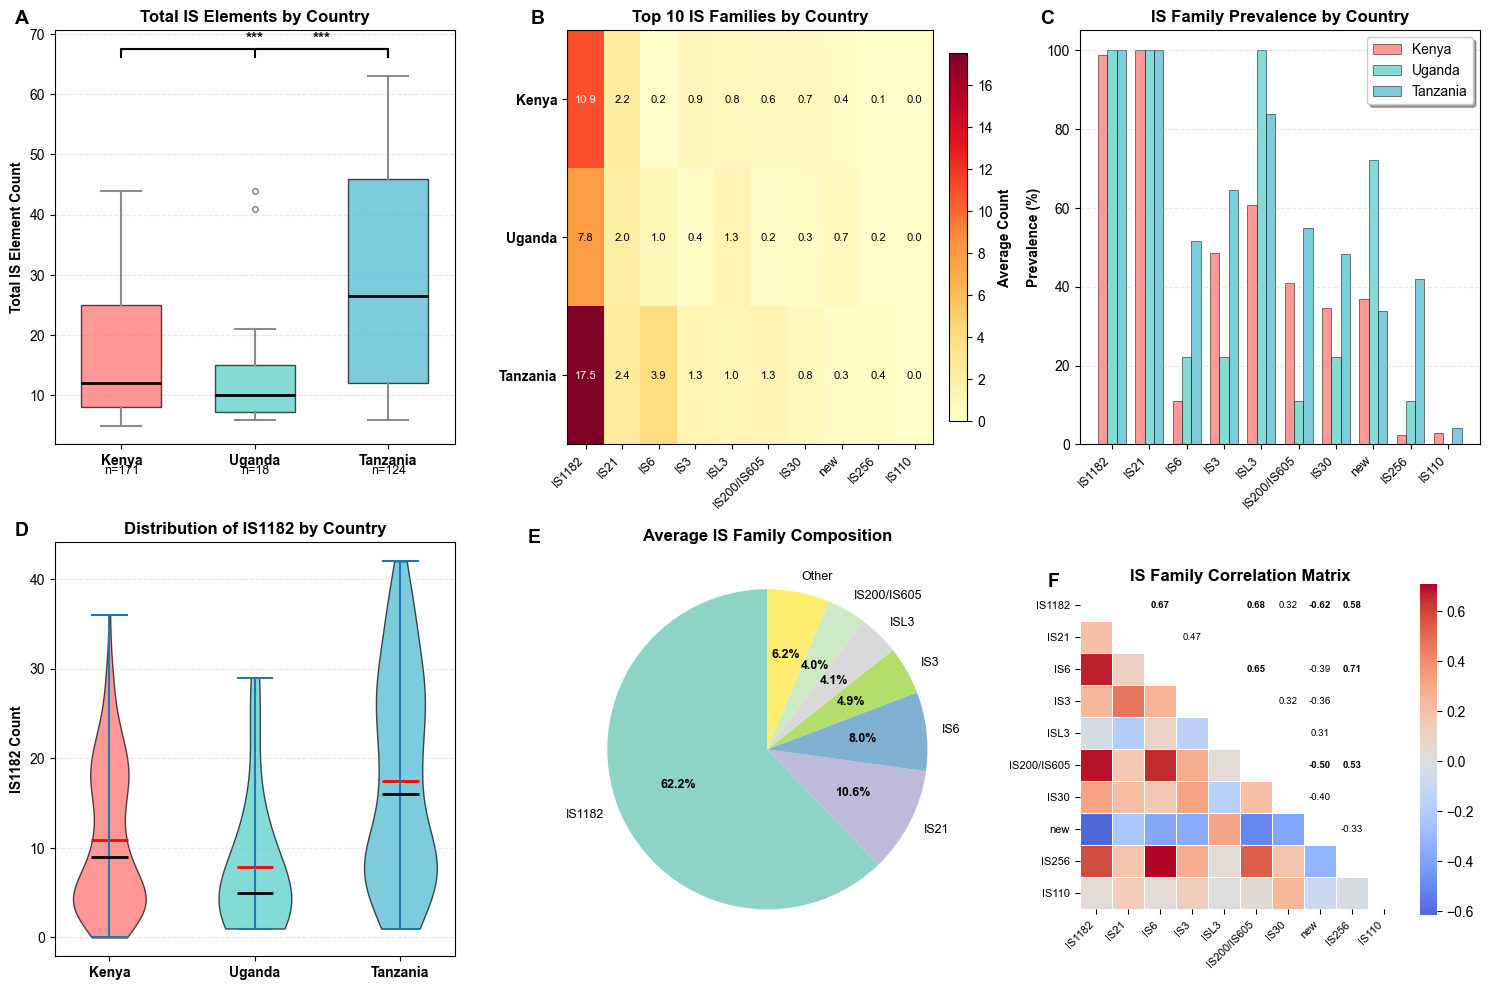

In [2]:
# Set up the figure
fig = plt.figure(figsize=(15, 10))
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'Arial'

# Panel A: Boxplot of total IS elements by country
ax1 = plt.subplot(2, 3, 1)
boxplot_data = [kenya_total, uganda_total, tanzania_total]
box = ax1.boxplot(boxplot_data, patch_artist=True, widths=0.6)

# Customize boxplot
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for whisker in box['whiskers']:
    whisker.set(color='#8B8B8B', linewidth=1.5, linestyle='-')
for cap in box['caps']:
    cap.set(color='#8B8B8B', linewidth=1.5)
for median in box['medians']:
    median.set(color='black', linewidth=2)
for flier in box['fliers']:
    flier.set(marker='o', color='#8B8B8B', alpha=0.5, markersize=4)

# Add significance bars
y_max = max([max(data) for data in boxplot_data])
y_pos = y_max * 1.05

# Draw significance bars based on corrected p-values
sig_y = y_pos
for i, (comparison, p_corrected) in enumerate(zip(comparisons, corrected_p)):
    if p_corrected < 0.05:
        x1, x2 = i + 1, i + 2
        if i == 0:  # Kenya vs Uganda
            x1, x2 = 1, 2
        elif i == 1:  # Kenya vs Tanzania
            x1, x2 = 1, 3
        else:  # Uganda vs Tanzania
            x1, x2 = 2, 3
        
        ax1.plot([x1, x1, x2, x2], [sig_y, sig_y*1.02, sig_y*1.02, sig_y], 
                lw=1.5, c='black')
        
        # Determine number of asterisks
        if p_corrected < 0.001:
            sig_text = '***'
        elif p_corrected < 0.01:
            sig_text = '**'
        else:
            sig_text = '*'
        
        ax1.text((x1+x2)/2, sig_y*1.03, sig_text, 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(['Kenya', 'Uganda', 'Tanzania'], fontweight='bold')
ax1.set_ylabel('Total IS Element Count', fontweight='bold')
ax1.set_title('Total IS Elements by Country', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')

# Add sample size annotations
for i, (country, data) in enumerate(zip(['Kenya', 'Uganda', 'Tanzania'], boxplot_data)):
    ax1.text(i+1, ax1.get_ylim()[0] - (ax1.get_ylim()[1]-ax1.get_ylim()[0])*0.05, 
            f'n={len(data)}', ha='center', va='top', fontsize=9)

# Panel B: Heatmap of average IS family abundance by country
ax2 = plt.subplot(2, 3, 2)
top_families = prevalence.head(10).index.tolist()
heatmap_data = []
for country in ['Kenya', 'Uganda', 'Tanzania']:
    country_means = df_clean[df_clean['Country'] == country][top_families].mean()
    heatmap_data.append(country_means.values)

heatmap_data = np.array(heatmap_data)

# Create heatmap
im = ax2.imshow(heatmap_data, aspect='auto', cmap='YlOrRd', interpolation='nearest')

# Customize heatmap
ax2.set_xticks(range(len(top_families)))
ax2.set_xticklabels(top_families, rotation=45, ha='right', fontsize=9)
ax2.set_yticks(range(3))
ax2.set_yticklabels(['Kenya', 'Uganda', 'Tanzania'], fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Average Count', fontweight='bold')

# Add values to heatmap cells
for i in range(3):
    for j in range(len(top_families)):
        text = ax2.text(j, i, f'{heatmap_data[i, j]:.1f}',
                       ha="center", va="center", color="black" if heatmap_data[i, j] < np.max(heatmap_data)/2 else "white",
                       fontsize=8)

ax2.set_title('Top 10 IS Families by Country', fontsize=12, fontweight='bold')

# Panel C: Prevalence of IS families
ax3 = plt.subplot(2, 3, 3)
prevalence_by_country = {}
for country in ['Kenya', 'Uganda', 'Tanzania']:
    country_data = df_clean[df_clean['Country'] == country]
    prevalence_vals = []
    for family in top_families:
        prevalence_vals.append((country_data[family] > 0).mean() * 100)
    prevalence_by_country[country] = prevalence_vals

x = np.arange(len(top_families))
width = 0.25
for i, (country, color) in enumerate(zip(['Kenya', 'Uganda', 'Tanzania'], colors)):
    ax3.bar(x + i*width, prevalence_by_country[country], width, 
           label=country, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)

ax3.set_xticks(x + width)
ax3.set_xticklabels(top_families, rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Prevalence (%)', fontweight='bold')
ax3.set_title('IS Family Prevalence by Country', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')

# Panel D: Distribution of IS1182 (most abundant family)
ax4 = plt.subplot(2, 3, 4)
family_to_plot = 'IS1182'  # Most abundant based on prevalence
violin_data = [df_clean[df_clean['Country'] == country][family_to_plot] 
               for country in ['Kenya', 'Uganda', 'Tanzania']]

parts = ax4.violinplot(violin_data, showmeans=True, showmedians=True)

# Customize violins
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')

parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

ax4.set_xticks([1, 2, 3])
ax4.set_xticklabels(['Kenya', 'Uganda', 'Tanzania'], fontweight='bold')
ax4.set_ylabel(f'{family_to_plot} Count', fontweight='bold')
ax4.set_title(f'Distribution of {family_to_plot} by Country', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

# Panel E: IS family composition pie chart (average composition)
ax5 = plt.subplot(2, 3, 5)
overall_means = df_clean[top_families].mean()
# Get top 6 for readability
top6 = overall_means.nlargest(6)
other = overall_means.sum() - top6.sum()
pie_data = pd.concat([top6, pd.Series({'Other': other})])

colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = ax5.pie(pie_data.values, labels=pie_data.index, 
                                   colors=colors_pie, autopct='%1.1f%%',
                                   startangle=90, textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

ax5.set_title('Average IS Family Composition', fontsize=12, fontweight='bold')

# Panel F: Correlation heatmap between IS families
ax6 = plt.subplot(2, 3, 6)
# Calculate correlation matrix for top families
corr_matrix = df_clean[top_families].corr()

# Create triangular mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": 0.8},
            ax=ax6, annot=False)

# Adjust annotation for significant correlations only
for i in range(len(top_families)):
    for j in range(i+1, len(top_families)):
        if abs(corr_matrix.iloc[i, j]) > 0.3:  # Only show strong correlations
            ax6.text(j+0.5, i+0.5, f'{corr_matrix.iloc[i, j]:.2f}',
                    ha='center', va='center', fontsize=7,
                    fontweight='bold' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'normal')

ax6.set_xticklabels(top_families, rotation=45, ha='right', fontsize=8)
ax6.set_yticklabels(top_families, rotation=0, fontsize=8)
ax6.set_title('IS Family Correlation Matrix', fontsize=12, fontweight='bold')

# Add panel labels
for i, ax in enumerate([ax1, ax2, ax3, ax4, ax5, ax6]):
    ax.text(-0.1, 1.05, chr(65+i), transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('IS_element_analysis_figure.png', dpi=300, bbox_inches='tight')
plt.savefig('IS_element_analysis_figure.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
# Save supplementary table
supplementary_table.to_csv('Supplementary_Table_IS_Elements.csv', index=False)

# Generate summary statistics by country
summary_stats = df_clean.groupby('Country').agg({
    'Total_IS': ['mean', 'median', 'std', 'min', 'max', 'count']
}).round(2)

print("\n" + "="*60)
print("SUMMARY STATISTICS BY COUNTRY")
print("="*60)
print(summary_stats)

# Generate additional statistics for manuscript
print("\n" + "="*60)
print("RESULTS FOR MANUSCRIPT")
print("="*60)

# Calculate percentage of samples with different IS families
print("\nPercentage of samples containing at least one copy of each IS family:")
for family in prevalence.index[:5]:  # Top 5 families
    pct_kenya = (df_clean[df_clean['Country'] == 'Kenya'][family] > 0).mean() * 100
    pct_uganda = (df_clean[df_clean['Country'] == 'Uganda'][family] > 0).mean() * 100
    pct_tanzania = (df_clean[df_clean['Country'] == 'Tanzania'][family] > 0).mean() * 100
    print(f"\n{family}:")
    print(f"  Kenya: {pct_kenya:.1f}%")
    print(f"  Uganda: {pct_uganda:.1f}%")
    print(f"  Tanzania: {pct_tanzania:.1f}%")

# Calculate diversity metrics
print("\nShannon diversity index of IS families by country:")
from scipy.stats import entropy

for country in ['Kenya', 'Uganda', 'Tanzania']:
    country_data = df_clean[df_clean['Country'] == country]
    # Calculate proportions of each IS family
    total_counts = country_data[is_families].sum().sum()
    proportions = country_data[is_families].sum() / total_counts
    # Remove zero proportions
    proportions = proportions[proportions > 0]
    shannon = entropy(proportions, base=2)  # Base 2 for bits
    print(f"  {country}: H' = {shannon:.3f} bits")


SUMMARY STATISTICS BY COUNTRY
         Total_IS                            
             mean median    std min max count
Country                                      
Kenya       16.71   12.0   9.77   5  44   171
Tanzania    29.27   26.5  17.46   6  63   124
Uganda      13.89   10.0  11.24   6  44    18

RESULTS FOR MANUSCRIPT

Percentage of samples containing at least one copy of each IS family:

IS1182:
  Kenya: 98.8%
  Uganda: 100.0%
  Tanzania: 100.0%

IS21:
  Kenya: 100.0%
  Uganda: 100.0%
  Tanzania: 100.0%

IS6:
  Kenya: 11.1%
  Uganda: 22.2%
  Tanzania: 51.6%

IS3:
  Kenya: 48.5%
  Uganda: 22.2%
  Tanzania: 64.5%

ISL3:
  Kenya: 60.8%
  Uganda: 100.0%
  Tanzania: 83.9%

Shannon diversity index of IS families by country:
  Kenya: H' = 1.819 bits
  Uganda: H' = 2.110 bits
  Tanzania: H' = 2.070 bits


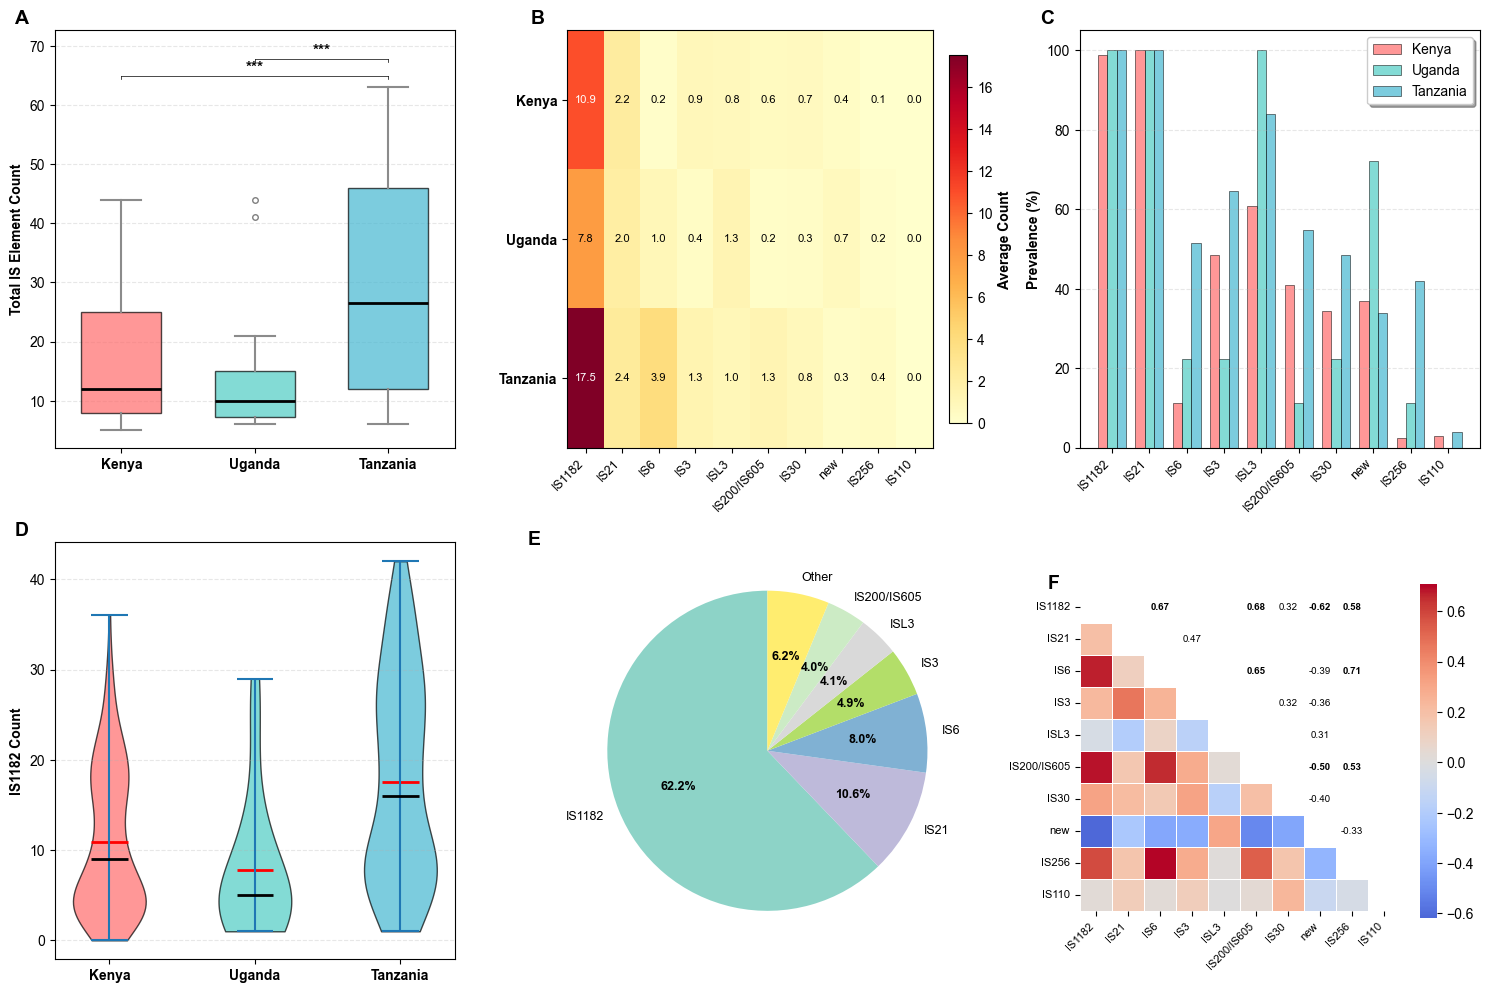

In [9]:
# Set up the figure
fig = plt.figure(figsize=(15, 10))
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'Arial'

# Panel A: Boxplot of total IS elements by country
ax1 = plt.subplot(2, 3, 1)
boxplot_data = [kenya_total, uganda_total, tanzania_total]
box = ax1.boxplot(boxplot_data, patch_artist=True, widths=0.6)

# Customize boxplot
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for whisker in box['whiskers']:
    whisker.set(color='#8B8B8B', linewidth=1.5, linestyle='-')
for cap in box['caps']:
    cap.set(color='#8B8B8B', linewidth=1.5)
for median in box['medians']:
    median.set(color='black', linewidth=2)
for flier in box['fliers']:
    flier.set(marker='o', color='#8B8B8B', alpha=0.5, markersize=4)

# Set axis labels
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(['Kenya', 'Uganda', 'Tanzania'], fontweight='bold')
ax1.set_ylabel('Total IS Element Count', fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')


# Get y limits for positioning significance bars
y_min, y_max = ax1.get_ylim()
data_max = max([max(data) for data in boxplot_data])

# Set positions for significance bars
bar_height = 0.03 * (y_max - y_min)
bar_y_start = data_max + bar_height
bar_y_step = bar_height * 1.5

# Draw significance bars for significant comparisons
significant_comparisons = []
for i, (comparison, p_corrected) in enumerate(zip(comparisons, corrected_p)):
    if p_corrected < 0.05:
        significant_comparisons.append((comparison, p_corrected))

# Plot each significant comparison with separate bar
for i, ((country1, country2), p_corrected) in enumerate(significant_comparisons):
    # Map countries to x positions
    country_to_x = {'Kenya': 1, 'Uganda': 2, 'Tanzania': 3}
    x1 = country_to_x[country1]
    x2 = country_to_x[country2]
    
    # Calculate y position for this bar
    bar_y = bar_y_start + (i * bar_y_step)
    
    # Draw the horizontal line
    ax1.plot([x1, x2], [bar_y, bar_y], color='black', linewidth=0.5, linestyle='-')
    
    # Draw the vertical ends
    ax1.plot([x1, x1], [bar_y - bar_height/4, bar_y], color='black', linewidth=0.5)
    ax1.plot([x2, x2], [bar_y - bar_height/4, bar_y], color='black', linewidth=0.5)
    
    # Determine number of asterisks
    if p_corrected < 0.001:
        sig_text = '***'
    elif p_corrected < 0.01:
        sig_text = '**'
    else:
        sig_text = '*'
    
    # Add asterisk above the middle of the bar
    ax1.text((x1 + x2) / 2, bar_y + bar_height/8, sig_text, 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Adjust ylim to accommodate significance bars
if significant_comparisons:
    ax1.set_ylim(y_min, bar_y_start + len(significant_comparisons) * bar_y_step + bar_height)

# Panel B: Heatmap of average IS family abundance by country
ax2 = plt.subplot(2, 3, 2)
top_families = prevalence.head(10).index.tolist()
heatmap_data = []
for country in ['Kenya', 'Uganda', 'Tanzania']:
    country_means = df_clean[df_clean['Country'] == country][top_families].mean()
    heatmap_data.append(country_means.values)

heatmap_data = np.array(heatmap_data)

# Create heatmap
im = ax2.imshow(heatmap_data, aspect='auto', cmap='YlOrRd', interpolation='nearest')

# Customize heatmap
ax2.set_xticks(range(len(top_families)))
ax2.set_xticklabels(top_families, rotation=45, ha='right', fontsize=9)
ax2.set_yticks(range(3))
ax2.set_yticklabels(['Kenya', 'Uganda', 'Tanzania'], fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Average Count', fontweight='bold')

# Add values to heatmap cells
for i in range(3):
    for j in range(len(top_families)):
        text = ax2.text(j, i, f'{heatmap_data[i, j]:.1f}',
                       ha="center", va="center", color="black" if heatmap_data[i, j] < np.max(heatmap_data)/2 else "white",
                       fontsize=8)

# Panel C: Prevalence of IS families
ax3 = plt.subplot(2, 3, 3)
prevalence_by_country = {}
for country in ['Kenya', 'Uganda', 'Tanzania']:
    country_data = df_clean[df_clean['Country'] == country]
    prevalence_vals = []
    for family in top_families:
        prevalence_vals.append((country_data[family] > 0).mean() * 100)
    prevalence_by_country[country] = prevalence_vals

x = np.arange(len(top_families))
width = 0.25
for i, (country, color) in enumerate(zip(['Kenya', 'Uganda', 'Tanzania'], colors)):
    ax3.bar(x + i*width, prevalence_by_country[country], width, 
           label=country, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)

ax3.set_xticks(x + width)
ax3.set_xticklabels(top_families, rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Prevalence (%)', fontweight='bold')
ax3.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')

# Panel D: Distribution of IS1182 (most abundant family)
ax4 = plt.subplot(2, 3, 4)
family_to_plot = 'IS1182'  # Most abundant based on prevalence
violin_data = [df_clean[df_clean['Country'] == country][family_to_plot] 
               for country in ['Kenya', 'Uganda', 'Tanzania']]

parts = ax4.violinplot(violin_data, showmeans=True, showmedians=True)

# Customize violins
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')

parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

ax4.set_xticks([1, 2, 3])
ax4.set_xticklabels(['Kenya', 'Uganda', 'Tanzania'], fontweight='bold')
ax4.set_ylabel(f'{family_to_plot} Count', fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

# Panel E: IS family composition pie chart (average composition)
ax5 = plt.subplot(2, 3, 5)
overall_means = df_clean[top_families].mean()
# Get top 6 for readability
top6 = overall_means.nlargest(6)
other = overall_means.sum() - top6.sum()
pie_data = pd.concat([top6, pd.Series({'Other': other})])

colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = ax5.pie(pie_data.values, labels=pie_data.index, 
                                   colors=colors_pie, autopct='%1.1f%%',
                                   startangle=90, textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

# Panel F: Correlation heatmap between IS families
ax6 = plt.subplot(2, 3, 6)
# Calculate correlation matrix for top families
corr_matrix = df_clean[top_families].corr()

# Create triangular mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": 0.8},
            ax=ax6, annot=False)

# Adjust annotation for significant correlations only
for i in range(len(top_families)):
    for j in range(i+1, len(top_families)):
        if abs(corr_matrix.iloc[i, j]) > 0.3:  # Only show strong correlations
            ax6.text(j+0.5, i+0.5, f'{corr_matrix.iloc[i, j]:.2f}',
                    ha='center', va='center', fontsize=7,
                    fontweight='bold' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'normal')

ax6.set_xticklabels(top_families, rotation=45, ha='right', fontsize=8)
ax6.set_yticklabels(top_families, rotation=0, fontsize=8)

# Add panel labels
for i, ax in enumerate([ax1, ax2, ax3, ax4, ax5, ax6]):
    ax.text(-0.1, 1.05, chr(65+i), transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('IS_element_analysis_figure.png', dpi=300, bbox_inches='tight')
plt.savefig('IS_element_analysis_figure.pdf', dpi=300, bbox_inches='tight')
plt.show()